In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

subgoals
no_subgoals
subgoals
no_subgoals
subgoals
no_subgoals


({'subgoals': {3: 18.703921333333334,
   6: 45.09452000000001,
   12: 129.18089333333333},
  'no_subgoals': {3: 11.218644333333337, 6: 75.21809666666667, 12: 491.1564}},
 {'subgoals': {3: 8.53095, 6: 35.65025, 12: 140.035},
  'no_subgoals': {3: 10.39245, 6: 74.006, 12: 468.0685}})

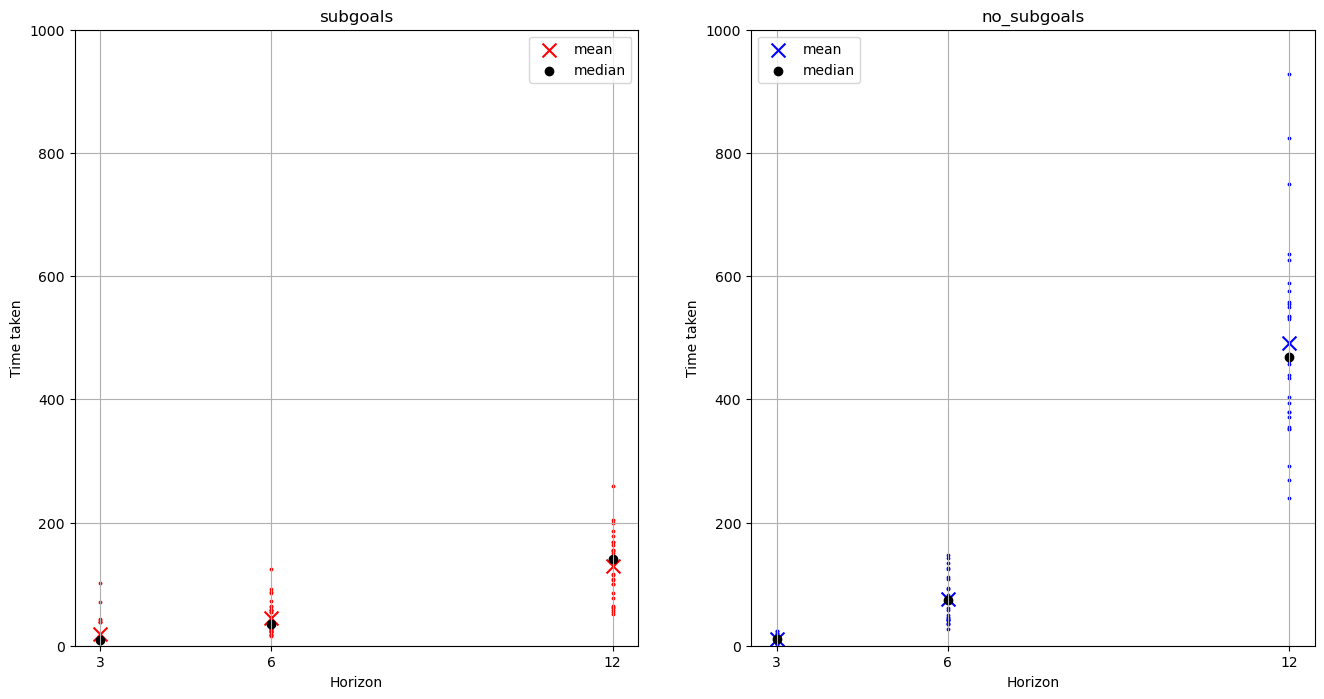

In [3]:
horizons = [3, 6, 12]
subfolders = ['subgoals', 'no_subgoals']

base_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/out/"
model = "test"
date = "25Aug"

data = {
    "subgoals": {
        3: [],
        6: [],
        12: []
    },
    "no_subgoals": {
        3: [],
        6: [],
        12: []
    }
}

data_means = {
    "subgoals":{
        3: [],
        6: [],
        12: []
    },
    "no_subgoals": {
        3: [],
        6: [],
        12: []
    },
}

data_medians = {
    "subgoals": {
        3: [],
        6: [],
        12: []
    },
    "no_subgoals": {
        3: [],
        6: [],
        12: []
    }
}


for horizon in horizons:
    
    for subfolder in subfolders:
        print(subfolder)
        p = os.path.join(base_folder, model, str(horizon), date, subfolder, "time_taken.txt")
        data_read = pd.read_csv(p, sep=" ", header=None)
        data[subfolder][horizon] = data_read.to_numpy()
        row_sums = data_read.sum(axis=1)

        data_means[subfolder][horizon] = row_sums.mean()
        data_medians[subfolder][horizon] = row_sums.median()


# scatter plot of the time taken for each horizon and subfolder
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# same subfolder, same color    
colors = ['r', 'b']
for i, subfolder in enumerate(subfolders):
    ax[i].set_xlabel("Horizon")
    ax[i].set_ylabel("Time taken")
    ax[i].set_xticks(horizons)
    ax[i].set_xticklabels(horizons)
    ax[i].set_ylim(0, 1000)
    ax[i].set_title(subfolder)
    ax[i].grid()
    for j, horizon in enumerate(horizons):
        ax[i].scatter(np.ones_like(data[subfolder][horizon])*horizon, data[subfolder][horizon], color=colors[i], s=3)
        ax[i].scatter(horizon, data_means[subfolder][horizon], color=colors[i], marker='x', label="mean", s=100)
        ax[i].scatter(horizon, data_medians[subfolder][horizon], color='black', marker='o', label="median")
        if j == 0:
            ax[i].legend()

data_means, data_medians

(11.218644333333337, 10.39245)

In [ ]:
# make a candlestick plot 

In [7]:
p = os.path.join(result_folder, subfolder, "per_subgoal_time_taken.txt")
data = pd.read_csv(p, sep=" ", header=None)
row_sums = data.sum(axis=1)
column_averages = data.mean(axis=0)
column_medians = data.median(axis=0)
# row_sums.mean(), , column_averages, column_medians
row_sums.median(), row_sums.mean()

FileNotFoundError: [Errno 2] No such file or directory: '/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/out/all_pushable/6/25Aug/subgoals_room2room_nobnb_bt/per_subgoal_time_taken.txt'

In [6]:
p = os.path.join(result_folder, subfolder, "per_subgoal_cost.txt")
data = pd.read_csv(p, sep=" ", header=None)
row_sums = data.sum(axis=1)
column_averages = data.mean(axis=0)
column_medians = data.median(axis=0)
# row_sums.mean(), , column_averages, column_medians
row_sums.median()

FileNotFoundError: [Errno 2] No such file or directory: '/home/dhruv/2024/projects/NAMO/out/turning_interactions/6/22Aug/subgoals_room2room_nobnb_walls_final2/per_subgoal_cost.txt'

0      10.30260
1      38.12750
2      17.66660
3       7.80835
4      43.46370
5      70.66110
6       5.84040
7      38.69300
8       5.16861
9     102.21900
10     42.22840
11     12.53420
12      4.41292
13      7.26451
14      5.57573
15      7.18825
16      5.83076
17      4.78105
18      6.42470
19     13.68280
20      8.88530
21     38.40440
22      6.28668
23      8.17660
24      8.97789
25      7.53851
26      4.94619
27     10.61710
28     10.35290
29      7.05789
dtype: float64


(18.703921333333334, 8.53095)

Text(0.5, 1.0, 'Candlestick Plot for Each Column')

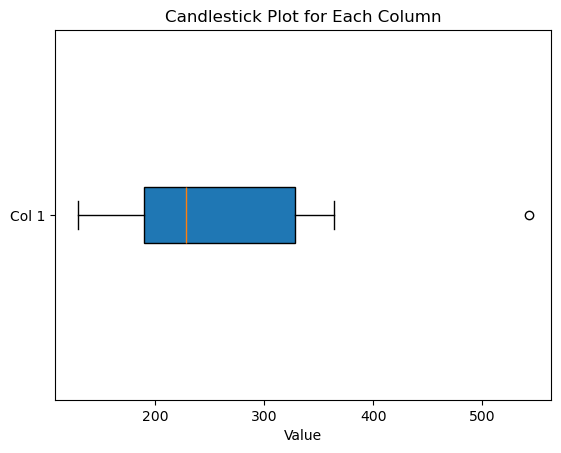

In [11]:
fig, ax = plt.subplots()
ax.boxplot(data.values, vert=False, patch_artist=True)
ax.set_yticklabels([f'Col {i+1}' for i in range(data.shape[1])])
plt.xlabel('Value')
plt.title('Candlestick Plot for Each Column')